In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from pathlib import Path
import sys
from torch.utils.data import Dataset, DataLoader, RandomSampler
import math
from collections import OrderedDict
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
logger.addHandler(logging.StreamHandler(sys.stdout))

In [2]:
import sagemaker
import boto3
from sagemaker.inputs import TrainingInput

#sagemaker pytorch container estimator related libraries
from sagemaker.pytorch import PyTorch
from sagemaker.pytorch import PyTorchModel


from sagemaker.estimator import Estimator
from sagemaker.model import Model
from sagemaker.predictor import Predictor

#general utility imports
import os
import glob
import pandas as pd
import numpy as np
import random

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/pydantic/_internal/_fields.py:192: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[03/18/25 04:55:13] INFO     Found credentials from IAM Role:                                   ]8;id=390588;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=873465;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [3]:
!pip install transformers datasets sentencepiece sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 221.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 138.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.7/781.7 kB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 154.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.2.0
    Uninstalling fsspec-2025.2.0:
      Successfully uninstalled fsspec-2025.2.0
  Attempting uninstall: dill
    Found existing installation: dill 0.3.9
    Uninstalling dill-0.3.9:
      Successfully uninstalled dill-0.3.9
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.17
    Uninstalling multiprocess-0.70.17:
      Successfully uninstalled multiprocess-0.70.17
ERROR: pip's dependency resolver does

In [4]:
!pip install torchinfo
from torchinfo import summary

In [5]:
!pip install sacrebleu bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 140.5 MB/s eta 0:00:00


In [6]:
!pip install evaluate
import evaluate

[03/18/25 04:55:44] INFO     PyTorch version 2.2.2 available.                                          ]8;id=475642;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/datasets/config.py\config.py]8;;\:]8;id=829654;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/datasets/config.py#54\54]8;;\

In [7]:
from transformers import AutoTokenizer

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [9]:
torch.__version__

'2.2.2'

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len, device):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model, device=device)
        position = torch.arange(0., max_len,
                                device=device).unsqueeze(1)
        div_term = torch.exp(torch.arange(0., d_model, 2, device=device) * -(math.log(10000.0) / d_model))
        pe_pos = torch.mul(position, div_term)
        pe[:, 0::2] = torch.sin(pe_pos)
        pe[:, 1::2] = torch.cos(pe_pos)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        out = self.pe[:, :x.size(1)].requires_grad_(False)
        return out

In [11]:
#del pe
pe_e = PositionalEncoding(d_model=768, dropout=0.1, max_len=512, device=device)
inp_tok = torch.tensor([5,8,78, 86, 78, 90, 45]).unsqueeze(0)
inp_tok, inp_tok.shape

(tensor([[ 5,  8, 78, 86, 78, 90, 45]]), torch.Size([1, 7]))

In [12]:
pe_e_e = pe_e(inp_tok)
pe_e_e, pe_e_e.shape

(tensor([[[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
            0.0000e+00,  1.0000e+00],
          [ 8.4147e-01,  5.4030e-01,  8.2843e-01,  ...,  1.0000e+00,
            1.0243e-04,  1.0000e+00],
          [ 9.0930e-01, -4.1615e-01,  9.2799e-01,  ...,  1.0000e+00,
            2.0486e-04,  1.0000e+00],
          ...,
          [-7.5680e-01, -6.5364e-01, -6.9153e-01,  ...,  1.0000e+00,
            4.0971e-04,  1.0000e+00],
          [-9.5892e-01,  2.8366e-01, -9.8573e-01,  ...,  1.0000e+00,
            5.1214e-04,  1.0000e+00],
          [-2.7942e-01,  9.6017e-01, -4.1267e-01,  ...,  1.0000e+00,
            6.1457e-04,  1.0000e+00]]], device='cuda:0'),
 torch.Size([1, 7, 768]))

In [13]:
class Embed(nn.Module):
    def __init__(self, vocab_size, embed_dim, ctx_len, do, device):
        super().__init__()
        self.tok_layer = nn.Embedding(vocab_size, embed_dim)
        self.pos_layer = PositionalEncoding(embed_dim, do, ctx_len, device)
        self.norm_do = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(do)
            )
        self.device = device
        self.ctx_len = ctx_len

    def forward(self, inp):
        inp = inp.to(self.device)
        len_inp = inp.shape[-1]
        try:
            assert len_inp <= self.ctx_len
        except:
            print("Err..Errr. Error...Bro..Length of supplied text exceeds context length defined.Exiting the program now")
            sys.exit(1)
        tok_embed = self.tok_layer(inp)
        pos_embed = self.pos_layer(inp)
        embed_tok_pos = tok_embed + pos_embed
        embed_out = self.norm_do(embed_tok_pos)
        return embed_out

In [14]:
inp_tok = torch.tensor([5,8,78, 86, 78, 90, 45]).unsqueeze(0)
inp_tok, inp_tok.shape

(tensor([[ 5,  8, 78, 86, 78, 90, 45]]), torch.Size([1, 7]))

In [15]:
emb = Embed(100, 768, 512, 0.1, device).to(device)

In [16]:
emb_out = emb(inp_tok.to(device))
emb_out.shape, emb_out

(torch.Size([1, 7, 768]),
 tensor([[[ 1.1950,  3.5097,  0.2107,  ..., -0.5340, -0.4245, -0.0000],
          [ 0.0000, -1.0434, -0.5692,  ...,  0.0110, -1.8177,  0.9913],
          [-0.1695, -2.2950, -0.8954,  ...,  1.3441, -1.0648,  0.4652],
          ...,
          [-1.7617, -2.4001, -2.4190,  ...,  1.3638, -0.9710,  0.5119],
          [-0.0000,  0.5782, -1.2793,  ...,  0.0000,  0.2144,  1.6462],
          [ 0.7431,  1.5673, -0.6883,  ...,  1.7656,  0.7418, -0.1987]]],
        device='cuda:0', grad_fn=<NativeDropoutBackward0>))

In [17]:
summary(emb)

Layer (type:depth-idx)                   Param #
Embed                                    --
├─Embedding: 1-1                         76,800
├─PositionalEncoding: 1-2                --
│    └─Dropout: 2-1                      --
├─Sequential: 1-3                        --
│    └─LayerNorm: 2-2                    1,536
│    └─Dropout: 2-3                      --
Total params: 78,336
Trainable params: 78,336
Non-trainable params: 0

In [18]:
def att_mask(attention_mask, lookahead, cross_att, x=None):
    if cross_att:
        batch_dim = x[0]
        repeat = x[1]
    else:
        batch_dim = attention_mask.shape[0]
        repeat = len(attention_mask[0])

    mask =[]
    for i in range(batch_dim):
        am_interim = [attention_mask[i].tolist()] * repeat
        am_interim = torch.tensor(am_interim).unsqueeze(0)
        mask.append(am_interim)
    mask = torch.vstack(mask)
    if lookahead:
        inp_save = mask
        mask = torch.tril(torch.ones(mask.shape))
    mask = torch.where(mask == 0, -torch.inf, 0.0)
    return mask

In [19]:
attention_mask = torch.tensor([[1,1,1,1,0,0], [1,1,1,0,0,0]])
attention_mask.shape

torch.Size([2, 6])

In [20]:
mask  = att_mask(attention_mask, lookahead=False, cross_att=False, x=[2,9,6])

In [21]:
mask, mask.shape

(tensor([[[0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf]],
 
         [[0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf]]]),
 torch.Size([2, 6, 6]))

In [22]:
mask  = att_mask(attention_mask, lookahead=True, cross_att=False, x=[2,9,6])

In [23]:
mask, mask.shape

(tensor([[[0., -inf, -inf, -inf, -inf, -inf],
          [0., 0., -inf, -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., 0., -inf],
          [0., 0., 0., 0., 0., 0.]],
 
         [[0., -inf, -inf, -inf, -inf, -inf],
          [0., 0., -inf, -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., 0., -inf],
          [0., 0., 0., 0., 0., 0.]]]),
 torch.Size([2, 6, 6]))

In [24]:
mask  = att_mask(attention_mask, lookahead=False, cross_att=True, x=[2,9,6])

In [25]:
mask, mask.shape

(tensor([[[0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., -inf, -inf]],
 
         [[0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf]]]),
 torch.Size([2, 9, 6]))

In [26]:
attention_mask = torch.tensor([[1,1,1,1,1,1,0,0,0], [1,1,1,1,0,0,0,0,0]])
attention_mask.shape

torch.Size([2, 9])

In [27]:
mask  = att_mask(attention_mask, lookahead=False, cross_att=True, x=[2,6,9])
mask, mask.shape

(tensor([[[0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., 0., 0., 0., -inf, -inf, -inf]],
 
         [[0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf]]]),
 torch.Size([2, 6, 9]))

In [28]:
class Attention(nn.Module):
    def __init__(self, embed_dim, k_dim, do, device):
        super().__init__()
        self.embed_dim = embed_dim
        self.k_dim = k_dim
        self.query = nn.Linear(embed_dim, k_dim)
        self.key = nn.Linear(embed_dim, k_dim)
        self.value = nn.Linear(embed_dim, k_dim)
        self.att_do = nn.Dropout(do)
        self.device = device

    def forward(self, qry, ky, vlu, mask):
        q = self.query(qry)
        k = self.key(ky)
        v = self.value(vlu)
        qk = (q@k.transpose(1, 2))/(self.k_dim**0.5)
        mask = mask.to(self.device)
        qk_m = qk + mask
        qk_m_smax = torch.softmax(qk_m, dim=-1)
        qk_m_smax_do = self.att_do(qk_m_smax)
        qkv = qk_m_smax_do@v
        return qkv

In [29]:
class Attention_Block(nn.Module):
    def __init__(self, num_heads, embed_dim, k_dim, do, device):
        super().__init__()
        self.num_heads = num_heads
        self.heads_list = [Attention(embed_dim, k_dim, do, device) for i in range(num_heads)]
        self.heads = nn.ModuleList(self.heads_list)
        self.lin_do = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.Dropout(do)
        )

    def forward(self, q, k, v, mask):
        heads_list_out = [head(q, k, v, mask) for head in self.heads]
        att_head = torch.cat(heads_list_out, dim=-1)
        att_head_out = self.lin_do(att_head)
        return att_head_out

In [30]:
class Encoder_Block(nn.Module):
    def __init__(self, num_heads, embed_dim, k_dim, do, device):
        super().__init__()
        self.MHA = Attention_Block(num_heads, embed_dim, k_dim, do, device)
        self.mha_blk_end_layernorm = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim*4),
            nn.GELU(),
            nn.Linear(embed_dim*4, embed_dim),
            nn.Dropout(do)
            )
        self.enc_blk_end_layernorm = nn.LayerNorm(embed_dim)

    def forward(self, args_list):  #q, k, v, mask):
        x = args_list[0]
        mask = args_list[1]

        inp_start_att_block = x
        x = self.MHA(x, x, x, mask)

        x = x + inp_start_att_block
        x = self.mha_blk_end_layernorm(x)

        inp_start_ff_block = x
        x = self.ff(x)

        x = x + inp_start_ff_block
        x = self.enc_blk_end_layernorm(x)
        return [x, mask]

In [31]:
class Encoder(nn.Module):
    def __init__(self, num_layers, num_heads, vocab_size, embed_dim, k_dim, ctx_len, do, device):
        super().__init__()
        self.emb = Embed(vocab_size, embed_dim, ctx_len, do, device)
        self.layer_list = [Encoder_Block(num_heads, embed_dim, k_dim, do, device) for i in range(num_layers)]
        self.layers = nn.Sequential(*self.layer_list)

    def forward(self, input_ids, attention_mask):
        x = self.emb(input_ids)
        mask = att_mask(attention_mask, lookahead=False, cross_att=False, x=None)
        x = self.layers([x, mask])
        return x[0]

In [32]:
enc = Encoder(3, 6, 100, 768, 128, 100, 0.1, device).to(device)
enc

Encoder(
  (emb): Embed(
    (tok_layer): Embedding(100, 768)
    (pos_layer): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (norm_do): Sequential(
      (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (1): Dropout(p=0.1, inplace=False)
    )
  )
  (layers): Sequential(
    (0): Encoder_Block(
      (MHA): Attention_Block(
        (heads): ModuleList(
          (0-5): 6 x Attention(
            (query): Linear(in_features=768, out_features=128, bias=True)
            (key): Linear(in_features=768, out_features=128, bias=True)
            (value): Linear(in_features=768, out_features=128, bias=True)
            (att_do): Dropout(p=0.1, inplace=False)
          )
        )
        (lin_do): Sequential(
          (0): Linear(in_features=768, out_features=768, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
      )
      (mha_blk_end_layernorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
  

In [33]:
inp = torch.randint(1,100, (4,6))
am = torch.ones(inp.shape)
inp.shape, am.shape

(torch.Size([4, 6]), torch.Size([4, 6]))

In [34]:
out = enc(inp.to(device), am.to(device))
out.shape

torch.Size([4, 6, 768])

In [35]:
class Decoder_Block(nn.Module):
    def __init__(self, num_heads, embed_dim, k_dim, do, device, decoderonly=False):
        super().__init__()
        self.MHA_CAUSAL_ATTN = Attention_Block(num_heads, embed_dim, k_dim, do, device)
        self.mha_causal_end_layernorm = nn.LayerNorm(embed_dim)
        self.decoderonly = decoderonly
        if not decoderonly:
            self.MHA_CROSS_ATTN = Attention_Block(num_heads, embed_dim, k_dim, do, device)
            self.mha_cross_end_layernorm = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim*4),
            nn.GELU(),
            nn.Linear(embed_dim*4, embed_dim),
            nn.Dropout(do)
            )
        self.dec_blk_end_layernorm = nn.LayerNorm(embed_dim)

    def forward(self, args_list):
        q = args_list[0]
        enc_k = args_list[1] 
        enc_v = args_list[2] 
        causal_mask = args_list[3] 
        padding_mask = args_list[4]
        
        # Causal Attention Block
        #################################################
        inp_start_causal_att_block = q
        x = self.MHA_CAUSAL_ATTN(q, q, q, causal_mask)
        x = x + inp_start_causal_att_block
        x = self.mha_causal_end_layernorm(x)

        # Cross Attention Block
        ###################################################
        if not self.decoderonly:
            inp_end_causal_att_block = x
            x = self.MHA_CROSS_ATTN(x, enc_k, enc_v, padding_mask)
            x = x + inp_end_causal_att_block
            x = self.mha_cross_end_layernorm(x)
        ###################################################

        inp_start_ff_block = x
        x = self.ff(x)
        x = x + inp_start_ff_block
        x = self.dec_blk_end_layernorm(x)
        return [x, enc_k, enc_v, causal_mask, padding_mask]

In [36]:
class Decoder(nn.Module):
    def __init__(self, num_layers, num_heads, vocab_size, embed_dim, 
                 k_dim, ctx_len, do, device):
        super().__init__()
        self.emb = Embed(vocab_size, embed_dim, ctx_len, do, device)
        self.layer_list = [Decoder_Block(num_heads, embed_dim, k_dim, do, device) for i in range(num_layers)]
        self.layers = nn.Sequential(*self.layer_list)


    def forward(self, input_ids, attention_mask, enc_attention_mask, enc_k, enc_v):
        x = self.emb(input_ids)
        q = x
        dim = [x.shape[0], attention_mask.shape[1], enc_attention_mask.shape[1]]
        causal_mask = att_mask(attention_mask, lookahead=True, cross_att=False)
        padding_mask = att_mask(enc_attention_mask, lookahead=False, cross_att=True, x=dim)
        x = self.layers([q, enc_k, enc_v, causal_mask, padding_mask])
        return x[0]

In [37]:
inp = torch.randint(1,100, (3,6))
am = torch.ones(inp.shape)
inp.shape, am.shape

(torch.Size([3, 6]), torch.Size([3, 6]))

In [38]:
dec = Decoder(3, 6, 100, 768, 128, 100, 0.1, device).to(device)
dec

Decoder(
  (emb): Embed(
    (tok_layer): Embedding(100, 768)
    (pos_layer): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (norm_do): Sequential(
      (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (1): Dropout(p=0.1, inplace=False)
    )
  )
  (layers): Sequential(
    (0): Decoder_Block(
      (MHA_CAUSAL_ATTN): Attention_Block(
        (heads): ModuleList(
          (0-5): 6 x Attention(
            (query): Linear(in_features=768, out_features=128, bias=True)
            (key): Linear(in_features=768, out_features=128, bias=True)
            (value): Linear(in_features=768, out_features=128, bias=True)
            (att_do): Dropout(p=0.1, inplace=False)
          )
        )
        (lin_do): Sequential(
          (0): Linear(in_features=768, out_features=768, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
      )
      (mha_causal_end_layernorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (MHA_

In [39]:
inp_e = torch.randint(1,100, (3,7))
am_e = torch.ones(inp_e.shape)
inp_e.shape, am_e.shape, inp_e

(torch.Size([3, 7]),
 torch.Size([3, 7]),
 tensor([[63, 48, 36, 81, 14,  8, 52],
         [ 3, 74, 40, 43, 39, 97, 42],
         [64, 24, 82, 34, 95, 68, 14]]))

In [40]:
out_e = enc(inp_e.to(device), am_e.to(device))
out_e, out_e.shape

(tensor([[[ 1.1766, -1.1428, -0.8457,  ...,  0.8276, -0.7472,  1.1234],
          [ 1.1447, -0.1647, -0.0913,  ...,  0.2880, -0.3834, -2.2070],
          [-0.0963, -0.6533,  1.6788,  ...,  0.8939, -1.3002, -0.6684],
          ...,
          [ 0.1071,  0.1332, -2.5463,  ...,  0.3710, -0.7203,  0.0028],
          [ 0.0573,  0.1657, -1.4973,  ...,  0.0735, -1.2654,  0.5362],
          [-0.6816,  1.3595,  0.1442,  ...,  0.2040, -1.5296,  1.0707]],
 
         [[-0.6273,  0.2016, -0.8343,  ...,  0.3900,  0.0182,  0.2500],
          [-0.1908,  0.1123,  0.0413,  ..., -1.1523,  0.7521, -1.1902],
          [-0.4766,  0.5897,  0.2150,  ..., -0.8201, -0.6012, -0.3388],
          ...,
          [-2.5247,  0.1281,  0.2185,  ..., -0.8547, -1.4541, -0.0370],
          [-1.1452,  0.7353, -0.8731,  ...,  1.4414,  0.0186,  0.1997],
          [ 0.6432,  0.4935, -0.9204,  ...,  0.2949,  0.1364,  0.3204]],
 
         [[ 1.0849,  1.4531,  0.1815,  ..., -0.3259, -0.6777, -2.0527],
          [ 0.0137, -1.2796,

In [41]:
out = dec(inp.to(device), am.to(device), am_e.to(device), out_e, out_e)
out.shape

torch.Size([3, 6, 768])

In [42]:
class Bro_Transformer(nn.Module):

    def __init__(self, num_layers, embed_dim, num_heads,
                 input_vocab_size, target_vocab_size, enc_ctx_len,
                 dec_ctx_len, device, do=0.1):
        super().__init__()
        k_dim = int(embed_dim/num_heads)

        self.encoder = Encoder(num_layers, num_heads, input_vocab_size, embed_dim, k_dim, enc_ctx_len, do, device)
        self.decoder = Decoder(num_layers, num_heads, target_vocab_size, embed_dim, k_dim, dec_ctx_len, do, device)
        self.final_layer = nn.Linear(embed_dim, target_vocab_size)

    def forward(self, enc_input_ids, dec_input_ids, enc_attention_mask, dec_attention_mask):

        enc_output = self.encoder(enc_input_ids, enc_attention_mask)
        dec_output = self.decoder(dec_input_ids, dec_attention_mask,
                                  enc_attention_mask, enc_output, enc_output)
        final_output = self.final_layer(dec_output)
        return final_output

In [43]:
inp_e = torch.randint(1,100, (2,6))
am_e = torch.ones(inp_e.shape)
inp_e.shape, am_e.shape

(torch.Size([2, 6]), torch.Size([2, 6]))

In [44]:
inp_d = torch.randint(1,100, (2,8))
am_d = torch.ones(inp_d.shape)
inp_d.shape, am_d.shape

(torch.Size([2, 8]), torch.Size([2, 8]))

In [45]:
bro_transformer = Bro_Transformer(3, 768, 6, 150, 160, 128, 128, device, 0.1).to(device)

In [46]:
bro_transformer

Bro_Transformer(
  (encoder): Encoder(
    (emb): Embed(
      (tok_layer): Embedding(150, 768)
      (pos_layer): PositionalEncoding(
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm_do): Sequential(
        (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (1): Dropout(p=0.1, inplace=False)
      )
    )
    (layers): Sequential(
      (0): Encoder_Block(
        (MHA): Attention_Block(
          (heads): ModuleList(
            (0-5): 6 x Attention(
              (query): Linear(in_features=768, out_features=128, bias=True)
              (key): Linear(in_features=768, out_features=128, bias=True)
              (value): Linear(in_features=768, out_features=128, bias=True)
              (att_do): Dropout(p=0.1, inplace=False)
            )
          )
          (lin_do): Sequential(
            (0): Linear(in_features=768, out_features=768, bias=True)
            (1): Dropout(p=0.1, inplace=False)
          )
        )
        (mha_blk_end_layernor

In [47]:
out = bro_transformer(inp_e.to(device), inp_d.to(device), am_e.to(device), am_d.to(device))

In [48]:
out.shape

torch.Size([2, 8, 160])

In [49]:
summary(bro_transformer)

Layer (type:depth-idx)                             Param #
Bro_Transformer                                    --
├─Encoder: 1-1                                     --
│    └─Embed: 2-1                                  --
│    │    └─Embedding: 3-1                         115,200
│    │    └─PositionalEncoding: 3-2                --
│    │    └─Sequential: 3-3                        1,536
│    └─Sequential: 2-2                             --
│    │    └─Encoder_Block: 3-4                     7,087,872
│    │    └─Encoder_Block: 3-5                     7,087,872
│    │    └─Encoder_Block: 3-6                     7,087,872
├─Decoder: 1-2                                     --
│    └─Embed: 2-3                                  --
│    │    └─Embedding: 3-7                         122,880
│    │    └─PositionalEncoding: 3-8                --
│    │    └─Sequential: 3-9                        1,536
│    └─Sequential: 2-4                             --
│    │    └─Decoder_Block: 3-10         

In [50]:
class BroGPT(nn.Module):
    def __init__(self, num_layers, num_heads, vocab_size,
                 embed_dim, ctx_len, do, device):
        super().__init__()
        k_dim = int(embed_dim/num_heads)
        self.emb = Embed(vocab_size, embed_dim, ctx_len, do, device)
        self.layer_list = [Decoder_Block(num_heads, embed_dim, k_dim, do, device, True) for i in range(num_layers)]
        self.layers = nn.Sequential(*self.layer_list)
        self.embed_vocab = nn.Linear(embed_dim, vocab_size)

    def forward(self, input_ids, attention_mask): # , enc_k=None, enc_v=None):
        x = self.emb(input_ids)
        causal_mask = att_mask(attention_mask, lookahead=True, cross_att=False)
        padding_mask = att_mask(attention_mask, lookahead=False, cross_att=False)
        #Let us fuse the two together. This is because causal should not be paying attention when there is a padding
        causal_mask = causal_mask + padding_mask
        padding_mask = None
        x = self.layers([x, x, x, causal_mask, padding_mask])
        x = self.embed_vocab(x[0])
        return x

In [51]:
brogpt = BroGPT(num_layers=4, num_heads=6, vocab_size=11000, embed_dim=768,
                ctx_len=512, do=0.1, device=device).to(device)

In [52]:
brogpt

BroGPT(
  (emb): Embed(
    (tok_layer): Embedding(11000, 768)
    (pos_layer): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (norm_do): Sequential(
      (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (1): Dropout(p=0.1, inplace=False)
    )
  )
  (layers): Sequential(
    (0): Decoder_Block(
      (MHA_CAUSAL_ATTN): Attention_Block(
        (heads): ModuleList(
          (0-5): 6 x Attention(
            (query): Linear(in_features=768, out_features=128, bias=True)
            (key): Linear(in_features=768, out_features=128, bias=True)
            (value): Linear(in_features=768, out_features=128, bias=True)
            (att_do): Dropout(p=0.1, inplace=False)
          )
        )
        (lin_do): Sequential(
          (0): Linear(in_features=768, out_features=768, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
      )
      (mha_causal_end_layernorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (ff)

In [53]:
inp_d = torch.randint(1,100, (4,9))
am_d = torch.ones(inp_d.shape)
inp_d.shape, am_d.shape

(torch.Size([4, 9]), torch.Size([4, 9]))

In [54]:
am_d[2]

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [55]:
am_d[2] = torch.tensor([1]*6 + [0]*3)
am_d[2], am_d[2].shape

(tensor([1., 1., 1., 1., 1., 1., 0., 0., 0.]), torch.Size([9]))

In [56]:
am_d[3] = torch.tensor([1]*7 + [0]*2)
am_d[3], am_d[3].shape

(tensor([1., 1., 1., 1., 1., 1., 1., 0., 0.]), torch.Size([9]))

In [57]:
am_d

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0., 0.]])

In [58]:
out = brogpt(inp_d.to(device), am_d.to(device))
out.shape

torch.Size([4, 9, 11000])

### Sagemaker Training Section

In [59]:
#Sagemaker related commands
sess = sagemaker.Session()
role = sagemaker.get_execution_role()
region = sess.boto_region_name
bucket = sess.default_bucket()
sess, role, region, bucket

[03/18/25 05:00:25] INFO     Found credentials from IAM Role:                                   ]8;id=832595;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=356508;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

                    INFO     Found credentials from IAM Role:                                   ]8;id=275123;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=843105;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

(<sagemaker.session.Session at 0x7f44d00bf0d0>,
 'arn:aws:iam::191013407134:role/service-role/AmazonSageMaker-ExecutionRole-20250124T222384',
 'us-east-1',
 'sagemaker-us-east-1-191013407134')

In [60]:
S3_LOC = f's3://{bucket}/fr-en-trans/'
S3_LOC

's3://sagemaker-us-east-1-191013407134/fr-en-trans/'

In [61]:
%pwd

'/home/ec2-user/SageMaker/MT/brotransformer'

In [62]:
#!wget https://gattonweb.uky.edu/faculty/lium/gai/en2fr.zip

In [63]:
##!unzip en2fr.zip

In [64]:
#!mkdir files
#!mv en2fr.csv ./files/

In [65]:
#!aws s3 cp ./files/en2fr.csv {S3_LOC}

In [66]:
!aws s3 ls --recursive {S3_LOC}

2025-03-16 03:29:51    5364599 fr-en-trans/en2fr.csv


In [67]:
hparams = {
    'bs': 256,
    'lrate': 0.0003,
    'num_epochs': 2,
    'environ': 'aws',
    'ckpt': 'none',
    'grad_accum_steps': 1, #set to 4 if cuda errors out
    'num_layers': 6,
    'embed_dim': 256,
    'num_heads': 8,
    'ctx_len': 128
}
hparams

{'bs': 256,
 'lrate': 0.0003,
 'num_epochs': 2,
 'environ': 'aws',
 'ckpt': 'none',
 'grad_accum_steps': 1,
 'num_layers': 6,
 'embed_dim': 256,
 'num_heads': 8,
 'ctx_len': 128}

In [68]:
# let us get image uri
training_image_uri = sagemaker.image_uris.retrieve(
    framework='pytorch', 
    version='2.0',
    instance_type='ml.g4dn.xlarge',
    region=region,
    py_version='py310',
    image_scope='training'
)
print(training_image_uri)

763104351884.dkr.ecr.us-east-1.amazonaws.com/pytorch-training:2.0-gpu-py310


In [69]:
train_uri = f'{S3_LOC}'
train_uri

's3://sagemaker-us-east-1-191013407134/fr-en-trans/'

In [70]:
s3_inp_tr = TrainingInput(
    s3_data = train_uri
    )
s3_inp_tr

In [71]:
data_channels = {
    'train': s3_inp_tr
    }
data_channels

{'train': <sagemaker.inputs.TrainingInput at 0x7f44d027f610>}

In [77]:
objective_metric_name = "average training loss"
objective_type = "Minimize"
metric_definitions = [{"Name": "average training loss", "Regex": "Average loss: ([0-9\\.]+)"},
                      {"Name": "training Perplexity", "Regex": "Perplexity: ([0-9\\.]+)"},
                      {"Name": "average validation loss", "Regex": "Validation Average loss: ([0-9\\.]+)"},
                      {"Name": "validation Perplexity", "Regex": "Validation Perplexity: ([0-9\\.]+)"}
                     ]
objective_metric_name, objective_type, metric_definitions

('average training loss',
 'Minimize',
 [{'Name': 'average training loss', 'Regex': 'Average loss: ([0-9\\.]+)'},
  {'Name': 'training Perplexity', 'Regex': 'Perplexity: ([0-9\\.]+)'},
  {'Name': 'average validation loss',
   'Regex': 'Validation Average loss: ([0-9\\.]+)'},
  {'Name': 'validation Perplexity',
   'Regex': 'Validation Perplexity: ([0-9\\.]+)'}])

In [78]:
ic=1
i_type = "ml.g4dn.xlarge"
ic, i_type

(1, 'ml.g4dn.xlarge')

In [81]:
hparams = {
    'bs': 256,
    'lrate': 0.0003,
    'num_epochs': 100,
    'environ': 'aws',
    'ckpt': 'none',
    'grad_accum_steps': 1, #set to 4 if cuda errors out
    'num_layers': 6,
    'embed_dim': 256,
    'num_heads': 8,
    'ctx_len': 128
}
hparams

{'bs': 256,
 'lrate': 0.0003,
 'num_epochs': 100,
 'environ': 'aws',
 'ckpt': 'none',
 'grad_accum_steps': 1,
 'num_layers': 6,
 'embed_dim': 256,
 'num_heads': 8,
 'ctx_len': 128}

In [82]:
est_fr_en = Estimator(
    image_uri=training_image_uri,
    role=role,
    source_dir='./scripts',
    entry_point='train-translation-fr-en.py',
    instance_count=ic,
    instance_type=i_type,
    base_job_name='en-fr-train',
    hyperparameters=hparams,
    metric_definitions=metric_definitions,
    objective_type=objective_type,
    objective_metric_name=objective_metric_name
)

est_fr_en.fit(
    inputs=data_channels,
    wait=True
)

[03/17/25 05:41:27] INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=655308;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=638660;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

[03/17/25 05:41:28] INFO     Creating training-job with name: en-fr-train-2025-03-17-05-41-27-984   ]8;id=387279;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=289613;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/session.py#1042\1042]8;;\

2025-03-17 05:41:32 Starting - Starting the training job...
...5-03-17 05:41:47 Starting - Preparing the instances for training
..25-03-17 05:42:18 Downloading - Downloading input data.
.................48 Downloading - Downloading the training image.
.bash: cannot set terminal process group (-1): Inappropriate ioctl for device..
bash: no job control in this shell
2025-03-17 05:46:15,727 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2025-03-17 05:46:15,745 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2025-03-17 05:46:15,756 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2025-03-17 05:46:15,762 sagemaker_pytorch_container.training INFO     Invoking user training script.
2025-03-17 05:46:17,708 sagemaker-training-toolkit INFO     Installing dependencies from requirements.txt:
/opt/conda/bin/python3.10 -m pip install -r requirements.txt
━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
## We see the model is overfitting. We will try to train for lesser number of epochs and then load the best weights obtained

In [90]:
hparams = {
    'bs': 256,
    'lrate': 0.0003,
    'num_epochs': 25,
    'environ': 'aws',
    'ckpt': 'none',
    'grad_accum_steps': 1, #set to 4 if cuda errors out
    'num_layers': 6,
    'embed_dim': 256,
    'num_heads': 8,
    'ctx_len': 128
}
hparams

{'bs': 256,
 'lrate': 0.0003,
 'num_epochs': 25,
 'environ': 'aws',
 'ckpt': 'none',
 'grad_accum_steps': 1,
 'num_layers': 6,
 'embed_dim': 256,
 'num_heads': 8,
 'ctx_len': 128}

In [91]:
est_fr_en_25e = Estimator(
    image_uri=training_image_uri,
    role=role,
    source_dir='./scripts',
    entry_point='train-translation-fr-en.py',
    instance_count=ic,
    instance_type=i_type,
    base_job_name='en-fr-train',
    hyperparameters=hparams,
    metric_definitions=metric_definitions,
    objective_type=objective_type,
    objective_metric_name=objective_metric_name
)

est_fr_en_25e.fit(
    inputs=data_channels,
    wait=True
)

[03/17/25 09:35:38] INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=354259;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=241327;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

                    INFO     Creating training-job with name: en-fr-train-2025-03-17-09-35-38-255   ]8;id=603439;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=866181;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/session.py#1042\1042]8;;\

2025-03-17 09:35:39 Starting - Starting the training job...
..25-03-17 09:35:59 Starting - Preparing the instances for training.
..25-03-17 09:36:31 Downloading - Downloading input data.
....................Downloading - Downloading the training image.
2025-03-17 09:40:18 Training - Training image download completed. Training in progress.bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2025-03-17 09:40:32,795 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2025-03-17 09:40:32,814 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2025-03-17 09:40:32,824 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2025-03-17 09:40:32,833 sagemaker_pytorch_container.training INFO     Invoking user training script.
2025-03-17 09:40:34,834 sagemaker-training-toolkit INFO     Installing dependencies from requirements.txt:

In [94]:
hparams = {
    'bs': 256,
    'lrate': 0.0003,
    'num_epochs': 100,
    'environ': 'aws',
    'ckpt': 'none',
    'grad_accum_steps': 1, #set to 4 if cuda errors out
    'num_layers': 6,
    'embed_dim': 256,
    'num_heads': 8,
    'ctx_len': 128
}
hparams

{'bs': 256,
 'lrate': 0.0003,
 'num_epochs': 100,
 'environ': 'aws',
 'ckpt': 'none',
 'grad_accum_steps': 1,
 'num_layers': 6,
 'embed_dim': 256,
 'num_heads': 8,
 'ctx_len': 128}

In [95]:
est_en_fr = Estimator(
    image_uri=training_image_uri,
    role=role,
    source_dir='./scripts',
    entry_point='train-translation-en-fr.py',
    instance_count=ic,
    instance_type=i_type,
    base_job_name='en-fr-train',
    hyperparameters=hparams,
    metric_definitions=metric_definitions,
    objective_type=objective_type,
    objective_metric_name=objective_metric_name
)

est_en_fr.fit(
    inputs=data_channels,
    wait=True
)

[03/17/25 10:49:59] INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=49674;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=972547;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

                    INFO     Creating training-job with name: en-fr-train-2025-03-17-10-49-59-372   ]8;id=44459;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=724729;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/session.py#1042\1042]8;;\

2025-03-17 10:50:01 Starting - Starting the training job...
..25-03-17 10:50:16 Starting - Preparing the instances for training.
..25-03-17 10:50:44 Downloading - Downloading input data.
.................09 Downloading - Downloading the training image.
.bash: cannot set terminal process group (-1): Inappropriate ioctl for device..
bash: no job control in this shell
2025-03-17 10:54:45,738 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2025-03-17 10:54:45,757 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2025-03-17 10:54:45,767 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2025-03-17 10:54:45,775 sagemaker_pytorch_container.training INFO     Invoking user training script.
2025-03-17 10:54:47,843 sagemaker-training-toolkit INFO     Installing dependencies from requirements.txt:
/opt/conda/bin/python3.10 -m pip install -r requirements.txt
━━━━━━━━━━━━━━━━━━━━━━

## French to English evaluation section

In [72]:
fr_en_100_est = Estimator.attach('en-fr-train-2025-03-17-05-41-27-984')

[03/18/25 05:02:53] INFO     Found credentials from IAM Role:                                   ]8;id=240674;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=777745;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

[03/18/25 05:02:54] INFO     Found credentials from IAM Role:                                   ]8;id=246956;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=621494;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   


2025-03-17 08:59:10 Starting - Preparing the instances for training
2025-03-17 08:59:10 Downloading - Downloading the training image
2025-03-17 08:59:10 Training - Training image download completed. Training in progress.
2025-03-17 08:59:10 Uploading - Uploading generated training model
2025-03-17 08:59:10 Completed - Training job completed


In [73]:
fr_en_100_est_ckpt = fr_en_100_est.model_data

In [74]:
fr_en_100_est_ckpt

's3://sagemaker-us-east-1-191013407134/en-fr-train-2025-03-17-05-41-27-984/output/model.tar.gz'

In [75]:
!ls -ltr

total 2980
-rw-rw-r-- 1 ec2-user ec2-user 1793553 Nov 24 11:36 en2fr.zip
drwxrwxr-x 2 ec2-user ec2-user    4096 Mar 15 09:25 files
drwxrwxr-x 4 ec2-user ec2-user    4096 Mar 15 09:33 tokenizers_dir
-rw-rw-r-- 1 ec2-user ec2-user  443285 Mar 15 15:14 Broencoder-decoder_v2-good working.ipynb
drwxrwxr-x 2 ec2-user ec2-user    4096 Mar 15 16:43 MT_bro
-rw-rw-r-- 1 ec2-user ec2-user  347730 Mar 15 17:38 Broencoder-decoder_v2-En_FrsuccessfulImplementation.ipynb
-rw-rw-r-- 1 ec2-user ec2-user  445206 Mar 18 05:03 Broencoder-decoder_v2-en-Fr-sagemaker.ipynb
drwxrwxr-x 2 ec2-user ec2-user    4096 Mar 18 05:03 fr-en-models


In [76]:
!aws s3 cp {fr_en_100_est_ckpt} ./fr-en-models/100epochs/

download: s3://sagemaker-us-east-1-191013407134/en-fr-train-2025-03-17-05-41-27-984/output/model.tar.gz to fr-en-models/100epochs/model.tar.gz


In [78]:
fr_en_25_est = Estimator.attach('en-fr-train-2025-03-17-09-35-38-255')


2025-03-17 10:31:27 Starting - Preparing the instances for training
2025-03-17 10:31:27 Downloading - Downloading the training image
2025-03-17 10:31:27 Training - Training image download completed. Training in progress.
2025-03-17 10:31:27 Uploading - Uploading generated training model
2025-03-17 10:31:27 Completed - Training job completed


In [79]:
fr_en_25_est_ckpt = fr_en_25_est.model_data
fr_en_25_est_ckpt

's3://sagemaker-us-east-1-191013407134/en-fr-train-2025-03-17-09-35-38-255/output/model.tar.gz'

In [80]:
!aws s3 ls --recursive {fr_en_25_est_ckpt}

2025-03-17 10:31:19  431855477 en-fr-train-2025-03-17-09-35-38-255/output/model.tar.gz


In [81]:
!aws s3 cp {fr_en_25_est_ckpt} ./fr-en-models/25epochs/

download: s3://sagemaker-us-east-1-191013407134/en-fr-train-2025-03-17-09-35-38-255/output/model.tar.gz to fr-en-models/25epochs/model.tar.gz


In [82]:
%cd ./fr-en-models/25epochs/
!ls -ltrh

/home/ec2-user/SageMaker/MT/brotransformer/fr-en-models/25epochs
total 412M
-rw-rw-r-- 1 ec2-user ec2-user 412M Mar 17 10:31 model.tar.gz


In [83]:
import tarfile

In [88]:
def process_extract(model_path):
    logger.info('Entering process_extract function now')
    logger.info(f'input_model path: {model_path}')
    logger.info('Extracting model.tar.gz')
    model_tar_path = model_path + 'model.tar.gz'
    model_tar = tarfile.open(model_tar_path)
    model_tar.extractall(model_path)
    model_tar.close()
    logger.info("Model extraction completed")
    return model_path

In [85]:
%cd ../..
%pwd

/home/ec2-user/SageMaker/MT/brotransformer


'/home/ec2-user/SageMaker/MT/brotransformer'

In [86]:
!ls -ltr

total 2988
-rw-rw-r-- 1 ec2-user ec2-user 1793553 Nov 24 11:36 en2fr.zip
drwxrwxr-x 2 ec2-user ec2-user    4096 Mar 15 09:25 files
drwxrwxr-x 4 ec2-user ec2-user    4096 Mar 15 09:33 tokenizers_dir
-rw-rw-r-- 1 ec2-user ec2-user  443285 Mar 15 15:14 Broencoder-decoder_v2-good working.ipynb
drwxrwxr-x 2 ec2-user ec2-user    4096 Mar 15 16:43 MT_bro
-rw-rw-r-- 1 ec2-user ec2-user  347730 Mar 15 17:38 Broencoder-decoder_v2-En_FrsuccessfulImplementation.ipynb
drwxrwxr-x 5 ec2-user ec2-user    4096 Mar 18 05:05 fr-en-models
-rw-rw-r-- 1 ec2-user ec2-user  452662 Mar 18 05:17 Broencoder-decoder_v2-en-Fr-sagemaker.ipynb


In [89]:
process_extract(model_path='./fr-en-models/100epochs/')

Entering process_extract function now


[03/18/25 05:19:00] INFO     Entering process_extract function now                                   ]8;id=623544;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=682438;file:///tmp/ipykernel_13167/642541686.py#2\2]8;;\

input_model path: ./fr-en-models/100epochs/


                    INFO     input_model path: ./fr-en-models/100epochs/                             ]8;id=157499;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=108448;file:///tmp/ipykernel_13167/642541686.py#3\3]8;;\

Extracting model.tar.gz


                    INFO     Extracting model.tar.gz                                                 ]8;id=280822;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=860572;file:///tmp/ipykernel_13167/642541686.py#4\4]8;;\

Model extraction completed


[03/18/25 05:19:02] INFO     Model extraction completed                                              ]8;id=407623;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=3885;file:///tmp/ipykernel_13167/642541686.py#9\9]8;;\

'./fr-en-models/100epochs/'

In [90]:
process_extract(model_path='./fr-en-models/25epochs/')

Entering process_extract function now


[03/18/25 05:19:50] INFO     Entering process_extract function now                                   ]8;id=228660;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=968055;file:///tmp/ipykernel_13167/642541686.py#2\2]8;;\

input_model path: ./fr-en-models/25epochs/


                    INFO     input_model path: ./fr-en-models/25epochs/                              ]8;id=995740;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=371165;file:///tmp/ipykernel_13167/642541686.py#3\3]8;;\

Extracting model.tar.gz


                    INFO     Extracting model.tar.gz                                                 ]8;id=86149;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=28834;file:///tmp/ipykernel_13167/642541686.py#4\4]8;;\

Model extraction completed


[03/18/25 05:19:53] INFO     Model extraction completed                                              ]8;id=988281;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=69066;file:///tmp/ipykernel_13167/642541686.py#9\9]8;;\

'./fr-en-models/25epochs/'

In [91]:
!ls -ltrh ./fr-en-models/25epochs/

total 871M
-rw-r--r-- 1 ec2-user ec2-user 230M Mar 17 10:09 model.pt
-rw-r--r-- 1 ec2-user ec2-user 230M Mar 17 10:30 train_end_model.pt
-rw-rw-r-- 1 ec2-user ec2-user 412M Mar 17 10:31 model.tar.gz


In [92]:
!ls -ltrh ./fr-en-models/100epochs/

total 436M
-rw-r--r-- 1 ec2-user ec2-user 230M Mar 17 08:58 ckpt_Epoch_100_Prplxty_1.043021352447469.pt
-rw-rw-r-- 1 ec2-user ec2-user 206M Mar 17 08:59 model.tar.gz


In [96]:
from sklearn.model_selection import train_test_split

In [130]:
class EN_FR_DS(Dataset):
    def __init__(self, df):
        self.data = df

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        fr_item = self.data.iloc[idx]['fr']
        en_item = self.data.iloc[idx]['en']
        return fr_item, en_item

In [131]:
def create_data_loaders(train_dir, batch_size):
    cpu_cores = os.cpu_count()
    csv_path = train_dir+'/en2fr.csv'
    df = pd.read_csv(csv_path)

    fr_tokenizer = AutoTokenizer.from_pretrained('Fardan/gpt2-frenchtranslation-tokenizer')
    en_tokenizer = AutoTokenizer.from_pretrained('Fardan/gpt2-englishtranslation-tokenizer')
    en_vocab_size = en_tokenizer.vocab_size
    fr_vocab_size = fr_tokenizer.vocab_size

    #df = sample_sort_ds(df, tokenizer)
    df_train, df_valid = train_test_split(df, test_size=0.01, random_state=42)
    train_ds = EN_FR_DS(df_train)
    valid_ds = EN_FR_DS(df_valid)
    
    return train_ds, valid_ds, fr_tokenizer, en_tokenizer, en_vocab_size, fr_vocab_size


In [132]:
train_ds, valid_ds, fr_tokenizer, en_tokenizer, en_vocab_size, fr_vocab_size = create_data_loaders('./files', 256)

In [133]:
len(train_ds), len(valid_ds),en_vocab_size, fr_vocab_size

(46701, 472, 11500, 11500)

In [134]:
train_ds[0], valid_ds[0]

(("Un homme en combinaison de jumpsuit jaune se tient sur un podium et accepte un trophée à côté d'un homme en combinaison rouge et en combinaison de jumpsuit.",
  'A man in a yellow jumpsuit is standing on a podium accepting a trophy next to a man in a red and with jumpsuit.'),
 ('Sa voiture est vraiment cool.', 'His car is really cool.'))

In [106]:
args = {
    'num_layers': 6,
    'embed_dim': 256,
    'num_heads': 8,
    'ctx_len': 128
}
args

{'num_layers': 6, 'embed_dim': 256, 'num_heads': 8, 'ctx_len': 128}

In [107]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [110]:
def net(args, device, fr_vocab_size, en_vocab_size):
    
    model = Bro_Transformer(num_layers=args['num_layers'], embed_dim=args['embed_dim'],
                            num_heads=args['num_heads'], input_vocab_size=fr_vocab_size,
                            target_vocab_size=en_vocab_size, enc_ctx_len=args['ctx_len'],
                            dec_ctx_len=args['ctx_len'], device=device, do=0.1)

    s = summary(model)
    logger.info(f"Total number of trainable parameters: {s.__dict__['trainable_params']}")

    model.to(device)
    return model

In [111]:
model = net(args, device, fr_vocab_size, en_vocab_size)

Total number of trainable parameters: 19903724


[03/18/25 05:37:31] INFO     Total number of trainable parameters: 19903724                          ]8;id=155305;file:///tmp/ipykernel_13167/352254767.py\352254767.py]8;;\:]8;id=178743;file:///tmp/ipykernel_13167/352254767.py#9\9]8;;\

In [112]:
summary(model)

Layer (type:depth-idx)                             Param #
Bro_Transformer                                    --
├─Encoder: 1-1                                     --
│    └─Embed: 2-1                                  --
│    │    └─Embedding: 3-1                         2,944,000
│    │    └─PositionalEncoding: 3-2                --
│    │    └─Sequential: 3-3                        512
│    └─Sequential: 2-2                             --
│    │    └─Encoder_Block: 3-4                     789,760
│    │    └─Encoder_Block: 3-5                     789,760
│    │    └─Encoder_Block: 3-6                     789,760
│    │    └─Encoder_Block: 3-7                     789,760
│    │    └─Encoder_Block: 3-8                     789,760
│    │    └─Encoder_Block: 3-9                     789,760
├─Decoder: 1-2                                     --
│    └─Embed: 2-3                                  --
│    │    └─Embedding: 3-10                        2,944,000
│    │    └─PositionalEncoding: 

In [114]:
fr_en_ckpt_path_1_100 = './fr-en-models/100epochs/ckpt_Epoch_100_Prplxty_1.043021352447469.pt'
!ls -lh {fr_en_ckpt_path_1_100}

-rw-r--r-- 1 ec2-user ec2-user 230M Mar 17 08:58 ./fr-en-models/100epochs/ckpt_Epoch_100_Prplxty_1.043021352447469.pt


In [116]:
fr_en_ckpt_path_2_25_best = './fr-en-models/25epochs/model.pt'
fr_en_ckpt_path_2_25_endtr = './fr-en-models/25epochs/train_end_model.pt'
!ls -lh {fr_en_ckpt_path_2_25_best} {fr_en_ckpt_path_2_25_endtr}

-rw-r--r-- 1 ec2-user ec2-user 230M Mar 17 10:09 ./fr-en-models/25epochs/model.pt
-rw-r--r-- 1 ec2-user ec2-user 230M Mar 17 10:30 ./fr-en-models/25epochs/train_end_model.pt


In [117]:
def load_model_ckpt(model, ckpt):
    model_ckpt = torch.load(ckpt)
    model.load_state_dict(model_ckpt['model_state_dict'])
    return model, model_ckpt['epoch']

In [118]:
model_100, epoch = load_model_ckpt(model, fr_en_ckpt_path_1_100)

In [119]:
epoch

100

In [120]:
bleu_metric = evaluate.load('sacrebleu')
bert_metric = evaluate.load('bertscore')

[03/18/25 05:48:45] WARNING  Matplotlib is building the font cache; this may take a moment.    ]8;id=655494;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/matplotlib/font_manager.py\font_manager.py]8;;\:]8;id=146173;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/matplotlib/font_manager.py#1095\1095]8;;\

[03/18/25 05:48:46] INFO     generated new fontManager                                         ]8;id=61383;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/matplotlib/font_manager.py\font_manager.py]8;;\:]8;id=779273;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/matplotlib/font_manager.py#1639\1639]8;;\

In [121]:
train_ds[0]

("Un homme en combinaison de jumpsuit jaune se tient sur un podium et accepte un trophée à côté d'un homme en combinaison rouge et en combinaison de jumpsuit.",
 '<|endoftext|>A man in a yellow jumpsuit is standing on a podium accepting a trophy next to a man in a red and with jumpsuit.')

In [124]:
def translate(src_text, tgt_text, tgt_start, src_tokenizer, tgt_tokenizer, bro_model, lang, compute_metrics=False):
    bro_model.eval()
    tokenized_src = src_tokenizer(src_text)
    tokenized_tgt = tgt_tokenizer(tgt_start)
    enc_input_ids = torch.tensor(tokenized_src.input_ids).unsqueeze(0).to(device)
    dec_input_ids = torch.tensor(tokenized_tgt.input_ids).unsqueeze(0).to(device)
    enc_attention_mask = torch.tensor(tokenized_src.attention_mask).unsqueeze(0).to(device)
    dec_attention_mask = torch.tensor(tokenized_tgt.attention_mask).unsqueeze(0).to(device)
    pred = 12345678
    while pred!=0:
        with torch.no_grad():
            output = bro_model(enc_input_ids=enc_input_ids, dec_input_ids=dec_input_ids,
                               enc_attention_mask=enc_attention_mask, dec_attention_mask=dec_attention_mask)
        prediction = torch.argmax(output, dim=-1)[0][-1].unsqueeze(0).unsqueeze(0)
        #print(prediction)
        pred = torch.argmax(output, dim=-1).tolist()[0][-1]
        dec_input_ids = torch.cat([dec_input_ids, prediction], dim=1).to(device)
        dec_attention_mask = torch.tensor([1]*len(dec_input_ids[0])).unsqueeze(0).to(device)
        #print(pred)
    pred_text = tgt_tokenizer.decode(dec_input_ids[0], skip_special_tokens=True)
    bleu = None
    bert_score = None
    if compute_metrics:
        bleu = bleu_metric.compute(predictions=[pred_text], references=[[tgt_text]])
        bert_score = bert_metric.compute(predictions=[pred_text], references=[[tgt_text]], lang=lang)
    return pred_text, bleu, bert_score

In [135]:
src_text = train_ds[0][0]
src_text

"Un homme en combinaison de jumpsuit jaune se tient sur un podium et accepte un trophée à côté d'un homme en combinaison rouge et en combinaison de jumpsuit."

In [136]:
tgt_start = '<|endoftext|>'
tgt_start

'<|endoftext|>'

In [137]:
tgt_text = train_ds[0][1]
tgt_text

'A man in a yellow jumpsuit is standing on a podium accepting a trophy next to a man in a red and with jumpsuit.'

In [139]:
src_text = train_ds[0][0]
tgt_text = train_ds[0][1]
tgt_start = '<|endoftext|>'
src_tokenizer = fr_tokenizer
tgt_tokenizer = en_tokenizer
bro_model = model
lang = 'en'
compute_metrics = True

In [140]:
pred_text, bleu, bert_score = translate(src_text=src_text,
                                        tgt_text=tgt_text,
                                        tgt_start=tgt_start,
                                        src_tokenizer=src_tokenizer,
                                        tgt_tokenizer=tgt_tokenizer,
                                        bro_model=model,
                                        lang=lang,
                                        compute_metrics=compute_metrics
                                       )

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [142]:
print(src_text)
print(tgt_text)
print(pred_text)
print("#######")
print(bleu, bert_score)

Un homme en combinaison de jumpsuit jaune se tient sur un podium et accepte un trophée à côté d'un homme en combinaison rouge et en combinaison de jumpsuit.
A man in a yellow jumpsuit is standing on a podium accepting a trophy next to a man in a red and with jumpsuit.
A man in a yellow jumpsuit is standing on a podium accepting a trophy next to a man in a red and with jumpsuit.
#######
{'score': 100.00000000000004, 'counts': [25, 24, 23, 22], 'totals': [25, 24, 23, 22], 'precisions': [100.0, 100.0, 100.0, 100.0], 'bp': 1.0, 'sys_len': 25, 'ref_len': 25} {'precision': [1.0], 'recall': [1.0], 'f1': [1.0], 'hashcode': 'roberta-large_L17_no-idf_version=0.3.12(hug_trans=4.49.0)'}


In [217]:
def translate_wrapper_fr_en(ds, ind, model, tgt_text_defined=True):
    if tgt_text_defined:
        src_text = ds[ind][0]
        tgt_text = ds[ind][1]
        compute_metrics = True
    else:
        src_text = ds
        tgt_text = "not defined"
        compute_metrics = False
    tgt_start = '<|endoftext|>'
    src_tokenizer = fr_tokenizer
    tgt_tokenizer = en_tokenizer
    lang = 'en'
    pred_text, bleu, bert_score = translate(src_text=src_text,
                                            tgt_text=tgt_text,
                                            tgt_start=tgt_start,
                                            src_tokenizer=src_tokenizer,
                                            tgt_tokenizer=tgt_tokenizer,
                                            bro_model=model,
                                            lang=lang,
                                            compute_metrics=compute_metrics
                                            )
    
    print(f'Source Text: {src_text}\n')
    print(f'Target Text: {tgt_text}\n')
    print(f'Predicted Text: {pred_text}\n')
    if compute_metrics:
        print(f'Bleu Score: {bleu["score"]}\nBert F1 Score: {bert_score["f1"]}')

In [218]:
import random

In [219]:
def draw_sample_test(ds, model, tgt_text_defined=True):
    if tgt_text_defined:
        samples = random.sample(range(400), 5)
    else:
        samples = [1]
    for i in samples:
        translate_wrapper_fr_en(ds, i, model, tgt_text_defined=tgt_text_defined)
        print(f"\n################################\n")

In [185]:
ds = valid_ds
draw_sample_test(ds, tgt_text_defined=True)

Source Text: Un homme regarde la réaction de sa jeune fille à un gâteau d'anniversaire fait maison.

Target Text: A man is watching his young daughter's reaction to a homemade birthday cake.

Predicted Text: A man watches out his young girl's part at a birthday cake.

Bleu Score: 16.1805547365076
Bert F1 Score: [0.9280321002006531]

################################

Source Text: Un homme en veste mauve se tient près de la roue d'un navire.

Target Text: A man in a mauve suit jacket stands near a ship's wheel.

Predicted Text: A man in a vest is standing near the wheel of a ship.

Bleu Score: 21.142141714303076
Bert F1 Score: [0.9430197477340698]

################################

Source Text: Le surfeur est au milieu d'une vague énorme.

Target Text: Surfer is in the middle of a huge wave.

Predicted Text: The surfer is in the middle of a huge wave.

Bleu Score: 78.60753021519781
Bert F1 Score: [0.9614478349685669]

################################

Source Text: Une jeune femme en pant

In [186]:
ds = train_ds
draw_sample_test(ds, tgt_text_defined=True)

Source Text: Une femme en étoile blanche équilibre un panier sur sa tête.

Target Text: A woman in a white apron balances a basket on her head.

Predicted Text: A woman in a white apron balances a basket on her head.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

Source Text: Trois hommes en uniforme de combat sont assis sur des briques avec un arbre en arrière-plan.

Target Text: Three men in combat uniforms are sitting on bricks with a tree in the background.

Predicted Text: Three men in combat uniforms are sitting on bricks with a tree in the background.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

Source Text: Un chien blanc avec des taches beige roule dans un champ.

Target Text: A white dog with beige spots is running through a field.

Predicted Text: A white dog with beige spots is running through a field.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

So

In [187]:
#Let us test model on some unknown texts not present in dataset

In [189]:
ds = "C'est ma voiture."
draw_sample_test(ds, tgt_text_defined=False)

Source Text: C'est ma voiture.

Target Text: not defined

Predicted Text: This is my car.


################################



In [191]:
ds = 'Une belle dame assise dans le parc'
draw_sample_test(ds, tgt_text_defined=False)

Source Text: Une belle dame assise dans le parc

Target Text: not defined

Predicted Text: A beautiful lady sitting in the park


################################



In [199]:
ds = "C'est une belle maison"
draw_sample_test(ds, tgt_text_defined=False)

Source Text: C'est une belle maison

Target Text: not defined

Predicted Text: It's a nice house


################################



In [200]:
ds = "Je t'aime tellement"
draw_sample_test(ds, tgt_text_defined=False)

Source Text: Je t'aime tellement

Target Text: not defined

Predicted Text: I love love looking so love


################################



#### As it looks like, model has done pretty ok job on validation dataset and is doing accurate prediction for training data. On unknown data as well, it is quite ok'ish. This is because of the limited text data. Model is overfitting. This means we need to pump more data during training

##### Let us calculate bleu score and bert score for entire training and validation dataset

In [230]:
def translate_wrapper_fr_en_fullds(ds, model):
    len_ds = len(ds)
    compute_metrics = True
    tgt_start = '<|endoftext|>'
    src_tokenizer = fr_tokenizer
    tgt_tokenizer = en_tokenizer
    bro_model = model
    lang = 'en'
    bleu_scores, bert_f1 = [], []
    for i in range(len_ds):
        src_text = ds[i][0]
        tgt_text = ds[i][1]
        pred_text, bleu, bert_score = translate(src_text=src_text,
                                                tgt_text=tgt_text,
                                                tgt_start=tgt_start,
                                                src_tokenizer=src_tokenizer,
                                                tgt_tokenizer=tgt_tokenizer,
                                                bro_model=model,
                                                lang=lang,
                                                compute_metrics=compute_metrics
                                               )
        bleu_scores.append(bleu["score"])
        bert_f1.append(bert_score["f1"][0])

    print(f'Totel number of item processed: {len(bleu_scores)}\n')
    print(f'Average Bleu Score is {sum(bleu_scores)/len(bleu_scores)}\n')
    print(f'Average Bert F1 Score is {sum(bert_f1)/len(bert_f1)}\n')

In [208]:
translate_wrapper_fr_en_fullds(valid_ds, model)

Totel number of item processed: 472

Average Bleu Score is 50.43313172220996

Average Bert F1 Score is 0.9618395691958525



##### We will do the same exercise for model trained for 25 epochs
- best model
- model at training end

In [209]:
def init_model_load_ckpt(args, device, fr_vocab_size, en_vocab_size, ckpt):
    model = net(args, device, fr_vocab_size, en_vocab_size)
    print(summary(model))
    model, epoch = load_model_ckpt(model, ckpt)
    print(f'chkpt epoch: {epoch}')
    return model

In [210]:
best_ckpt_25 = './fr-en-models/25epochs/model.pt'
train_end_ckpt_25 = './fr-en-models/25epochs/train_end_model.pt'
best_ckpt_25, train_end_ckpt_25

('./fr-en-models/25epochs/model.pt',
 './fr-en-models/25epochs/train_end_model.pt')

In [213]:
ckpt = best_ckpt_25
best_model_25 = init_model_load_ckpt(args, device, fr_vocab_size, en_vocab_size, ckpt)

Total number of trainable parameters: 19903724


[03/18/25 07:47:01] INFO     Total number of trainable parameters: 19903724                          ]8;id=82294;file:///tmp/ipykernel_13167/352254767.py\352254767.py]8;;\:]8;id=93954;file:///tmp/ipykernel_13167/352254767.py#9\9]8;;\

chkpt epoch: 13


In [220]:
ds = valid_ds
draw_sample_test(ds, best_model_25, tgt_text_defined=True)

Source Text: Deux hommes, l'un en noir et l'autre en gris, mènent une expérience scientifique.

Target Text: Two men, one in black and one in gray, are conducting a science experiment.

Predicted Text: Two men, one in black and one in gray is training, performing a science experiment.

Bleu Score: 66.54377827941899
Bert F1 Score: [0.9705596566200256]

################################

Source Text: Il s'est montré intéressé par le plan.

Target Text: He showed interest in the plan.

Predicted Text: He showed interested in the plan.

Bleu Score: 48.892302243490086
Bert F1 Score: [0.9825769662857056]

################################

Source Text: Un patineur ramenant un rail devant un magasin latin tandis que trois spectateurs regardent.

Target Text: A skater grinding down a rail in front of a latin store while three onlookers watch.

Predicted Text: A skater flying a rail in front of a store as three onlookers watch.

Bleu Score: 47.35407652832257
Bert F1 Score: [0.9693117141723633]

#

In [221]:
ds = train_ds
draw_sample_test(ds, best_model_25, tgt_text_defined=True)

Source Text: Un homme portant une chemise verte sur une rue.

Target Text: A man wearing a green shirt skateboarding down a street.

Predicted Text: A man wearing a green shirt on a street.

Bleu Score: 59.54165059120785
Bert F1 Score: [0.9694989323616028]

################################

Source Text: Un groupe d'étudiants du théâtre sautent en séquence sur la scène.

Target Text: A group of theater students are jumping in sequence on stage.

Predicted Text: A group of theater students are jumping in sequence on the stage.

Bleu Score: 79.10665071754353
Bert F1 Score: [0.9933761358261108]

################################

Source Text: Une mère aide sa petite fille avec ses skis une journée ensoleillée sur les pistes.

Target Text: A mother helping her small daughter with her skis on a sunny day on the slopes.

Predicted Text: A mother helps her little girl with her skis on a sunny day on the slopes.

Bleu Score: 66.3767913214782
Bert F1 Score: [0.9886668920516968]

#################

In [222]:
ds = "C'est ma voiture."
draw_sample_test(ds, best_model_25, tgt_text_defined=False)

Source Text: C'est ma voiture.

Target Text: not defined

Predicted Text: This is my car.


################################



In [223]:
ds = 'Une belle dame assise dans le parc'
draw_sample_test(ds, best_model_25, tgt_text_defined=False)

Source Text: Une belle dame assise dans le parc

Target Text: not defined

Predicted Text: A beautiful lady sitting in the park


################################



In [224]:
ds = "C'est une belle maison"
draw_sample_test(ds, best_model_25, tgt_text_defined=False)

Source Text: C'est une belle maison

Target Text: not defined

Predicted Text: It's a beautiful house


################################



In [229]:
ds = "Je t'aime tellement"
draw_sample_test(ds, best_model_25, tgt_text_defined=False)

Source Text: Je t'aime tellement

Target Text: not defined

Predicted Text: I like to love so much?


################################



In [231]:
ds = valid_ds
translate_wrapper_fr_en_fullds(ds, best_model_25)

Totel number of item processed: 472

Average Bleu Score is 50.03881841874447

Average Bert F1 Score is 0.9593700911786597



In [232]:
#now lets check it out for train end model

In [233]:
ckpt = train_end_ckpt_25
train_end_model_25 = init_model_load_ckpt(args, device, fr_vocab_size, en_vocab_size, ckpt)

Total number of trainable parameters: 19903724


[03/18/25 08:21:50] INFO     Total number of trainable parameters: 19903724                          ]8;id=430363;file:///tmp/ipykernel_13167/352254767.py\352254767.py]8;;\:]8;id=547311;file:///tmp/ipykernel_13167/352254767.py#9\9]8;;\

chkpt epoch: 25


In [234]:
ds = valid_ds
draw_sample_test(ds, train_end_model_25, tgt_text_defined=True)

Source Text: Tom s'est réjoui.

Target Text: Tom frowned.

Predicted Text: Tom was happy.

Bleu Score: 18.99589214128981
Bert F1 Score: [0.9284758567810059]

################################

Source Text: Un homme et une femme se promenant dans la rue herbacée du château.

Target Text: Man and lady walking up grassy lane of castle.

Predicted Text: A man and woman walking down the grassy street.

Bleu Score: 5.934202609760488
Bert F1 Score: [0.9374409317970276]

################################

Source Text: Un petit garçon en chemise verte joue dans l'eau avec une petite fille en chemise rose et jupe pourpre.

Target Text: A little boy in a green shirt is playing in water with a little girl in a pink shirt and purple skirt.

Predicted Text: A little boy in a green shirt plays in the water with a little girl in a little pink skirt and purple skirt.

Bleu Score: 59.70228993860436
Bert F1 Score: [0.982578694820404]

################################

Source Text: Un homme frappant un foot

In [235]:
ds = train_ds
draw_sample_test(ds, train_end_model_25, tgt_text_defined=True)

Source Text: Je suis trois ans plus jeune que vous.

Target Text: I'm three years younger than you.

Predicted Text: I'm three years younger than you.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

Source Text: Un homme est assis sur un banc avec ses pieds sur un planche à roulettes.

Target Text: A man is sitting on a bench with his feet on a skateboard.

Predicted Text: A man is sitting on a bench with his feet on a skateboard.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

Source Text: Prenez ce que vous voulez.

Target Text: Take whichever you want.

Predicted Text: Take whatever you want.

Bleu Score: 42.72870063962342
Bert F1 Score: [0.9715744853019714]

################################

Source Text: Un homme à cheveux longs prend une photo d'une plage.

Target Text: A long-haired man is taking a photo of a beach.

Predicted Text: A long-haired man is taking a photo of a beach.

Bleu Score: 100.0000

In [236]:
ds = "C'est ma voiture."
draw_sample_test(ds, train_end_model_25, tgt_text_defined=False)

Source Text: C'est ma voiture.

Target Text: not defined

Predicted Text: This is my car.


################################



In [237]:
ds = 'Une belle dame assise dans le parc'
draw_sample_test(ds, train_end_model_25, tgt_text_defined=False)

Source Text: Une belle dame assise dans le parc

Target Text: not defined

Predicted Text: A beautiful lady sitting in the park


################################



In [238]:
ds = "C'est une belle maison"
draw_sample_test(ds, train_end_model_25, tgt_text_defined=False)


Source Text: C'est une belle maison

Target Text: not defined

Predicted Text: This is a beautiful house nice house


################################



In [241]:
ds = "Je t'aime tellement"
draw_sample_test(ds, train_end_model_25, tgt_text_defined=False)

Source Text: Je t'aime tellement

Target Text: not defined

Predicted Text: I love so much for him so much


################################



In [243]:
%%time
ds = valid_ds
translate_wrapper_fr_en_fullds(ds, train_end_model_25)

Totel number of item processed: 472

Average Bleu Score is 50.75356438758378

Average Bert F1 Score is 0.9625280476727728

CPU times: user 7min 27s, sys: 8.95 s, total: 7min 36s
Wall time: 3min 48s


### English to French Translation section

In [244]:
en_fr_est = Estimator.attach('en-fr-train-2025-03-17-10-49-59-372')


2025-03-17 14:14:52 Starting - Preparing the instances for training
2025-03-17 14:14:52 Downloading - Downloading the training image
2025-03-17 14:14:52 Training - Training image download completed. Training in progress.
2025-03-17 14:14:52 Uploading - Uploading generated training model
2025-03-17 14:14:52 Completed - Training job completed


In [245]:
en_fr_est_ckpt = en_fr_est.model_data

In [246]:
en_fr_est_ckpt

's3://sagemaker-us-east-1-191013407134/en-fr-train-2025-03-17-10-49-59-372/output/model.tar.gz'

In [247]:
!aws s3 cp {en_fr_est_ckpt} ./en-fr-models/

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


download: s3://sagemaker-us-east-1-191013407134/en-fr-train-2025-03-17-10-49-59-372/output/model.tar.gz to en-fr-models/model.tar.gz


In [248]:
process_extract(model_path='./en-fr-models/')

Entering process_extract function now


[03/18/25 08:45:27] INFO     Entering process_extract function now                                   ]8;id=712204;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=268890;file:///tmp/ipykernel_13167/642541686.py#2\2]8;;\

input_model path: ./en-fr-models/


                    INFO     input_model path: ./en-fr-models/                                       ]8;id=732925;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=862912;file:///tmp/ipykernel_13167/642541686.py#3\3]8;;\

Extracting model.tar.gz


                    INFO     Extracting model.tar.gz                                                 ]8;id=69572;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=934890;file:///tmp/ipykernel_13167/642541686.py#4\4]8;;\

Model extraction completed


[03/18/25 08:45:30] INFO     Model extraction completed                                              ]8;id=979442;file:///tmp/ipykernel_13167/642541686.py\642541686.py]8;;\:]8;id=259915;file:///tmp/ipykernel_13167/642541686.py#9\9]8;;\

'./en-fr-models/'

In [249]:
%pwd

'/home/ec2-user/SageMaker/MT/brotransformer'

In [250]:
best_model_ckpt = './en-fr-models/model.pt'
train_end_model_ckpt = './en-fr-models/train_end_model.pt'

In [286]:
ckpt = best_model_ckpt
best_model_en_fr = init_model_load_ckpt(args, device, fr_vocab_size, en_vocab_size, ckpt)

Total number of trainable parameters: 19903724


[03/18/25 09:11:57] INFO     Total number of trainable parameters: 19903724                          ]8;id=344599;file:///tmp/ipykernel_13167/352254767.py\352254767.py]8;;\:]8;id=538377;file:///tmp/ipykernel_13167/352254767.py#9\9]8;;\

chkpt epoch: 15


In [287]:
class EN_FR_DS(Dataset):
    def __init__(self, df):
        self.data = df

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        en_item = self.data.iloc[idx]['en']
        fr_item = self.data.iloc[idx]['fr']
        return en_item, fr_item

In [288]:
def create_data_loaders(train_dir, batch_size):
    cpu_cores = os.cpu_count()
    csv_path = train_dir+'/en2fr.csv'
    df = pd.read_csv(csv_path)

    fr_tokenizer = AutoTokenizer.from_pretrained('Fardan/gpt2-frenchtranslation-tokenizer')
    en_tokenizer = AutoTokenizer.from_pretrained('Fardan/gpt2-englishtranslation-tokenizer')
    en_vocab_size = en_tokenizer.vocab_size
    fr_vocab_size = fr_tokenizer.vocab_size

    #df = sample_sort_ds(df, tokenizer)
    df_train, df_valid = train_test_split(df, test_size=0.01, random_state=42)
    train_ds = EN_FR_DS(df_train)
    valid_ds = EN_FR_DS(df_valid)
    
    return train_ds, valid_ds, fr_tokenizer, en_tokenizer, en_vocab_size, fr_vocab_size


In [289]:
train_ds, valid_ds, fr_tokenizer, en_tokenizer, en_vocab_size, fr_vocab_size = create_data_loaders('./files', 256)

In [290]:
train_ds[10], valid_ds[10]

(('It rained hard yesterday morning.', 'Il a plu dur hier matin.'),
 ("A curly-haired kid is throwing axes at bulls' head painted targets.",
  'Un enfant à cheveux curs jette des axes sur des cibles peintes à la tête de taureaux.'))

In [291]:
def translate_wrapper_en_fr(ds, ind, model, tgt_text_defined=True):
    if tgt_text_defined:
        src_text = ds[ind][0]
        tgt_text = ds[ind][1]
        compute_metrics = True
    else:
        src_text = ds
        tgt_text = "not defined"
        compute_metrics = False
    tgt_start = '<|endoftext|>'
    src_tokenizer = en_tokenizer
    tgt_tokenizer = fr_tokenizer
    lang = 'fr'
    pred_text, bleu, bert_score = translate(src_text=src_text,
                                            tgt_text=tgt_text,
                                            tgt_start=tgt_start,
                                            src_tokenizer=src_tokenizer,
                                            tgt_tokenizer=tgt_tokenizer,
                                            bro_model=model,
                                            lang=lang,
                                            compute_metrics=compute_metrics
                                            )
    
    print(f'Source Text: {src_text}\n')
    print(f'Target Text: {tgt_text}\n')
    print(f'Predicted Text: {pred_text}\n')
    if compute_metrics:
        print(f'Bleu Score: {bleu["score"]}\nBert F1 Score: {bert_score["f1"]}')

In [292]:
def draw_sample_test(ds, model, tgt_text_defined=True):
    if tgt_text_defined:
        samples = random.sample(range(400), 5)
    else:
        samples = [1]
    for i in samples:
        translate_wrapper_en_fr(ds, i, model, tgt_text_defined=tgt_text_defined)
        print(f"\n################################\n")

In [294]:
def translate_wrapper_en_fr_fullds(ds, model):
    len_ds = len(ds)
    compute_metrics = True
    tgt_start = '<|endoftext|>'
    src_tokenizer = en_tokenizer
    tgt_tokenizer = fr_tokenizer
    bro_model = model
    lang = 'fr'
    bleu_scores, bert_f1 = [], []
    for i in range(len_ds):
        src_text = ds[i][0]
        tgt_text = ds[i][1]
        pred_text, bleu, bert_score = translate(src_text=src_text,
                                                tgt_text=tgt_text,
                                                tgt_start=tgt_start,
                                                src_tokenizer=src_tokenizer,
                                                tgt_tokenizer=tgt_tokenizer,
                                                bro_model=model,
                                                lang=lang,
                                                compute_metrics=compute_metrics
                                               )
        bleu_scores.append(bleu["score"])
        bert_f1.append(bert_score["f1"][0])

    print(f'Totel number of item processed: {len(bleu_scores)}\n')
    print(f'Average Bleu Score is {sum(bleu_scores)/len(bleu_scores)}\n')
    print(f'Average Bert F1 Score is {sum(bert_f1)/len(bert_f1)}\n')

In [296]:
ds = valid_ds
draw_sample_test(ds, best_model_en_fr, tgt_text_defined=True)

Source Text: A child in a red shirt is sitting against a wall with a map while eating.

Target Text: Un enfant en chemise rouge est assis contre un mur avec une carte alors qu'il mange.

Predicted Text: Un enfant en chemise rouge est assis contre un mur avec une carte en mangeant.

Bleu Score: 75.7637442126685
Bert F1 Score: [0.9277660846710205]

################################

Source Text: A couple wearing white sweaters sit at a restaurant table.

Target Text: Un couple portant des chandails blancs assis à une table de restaurant.

Predicted Text: Un couple portant des chandails blancs s’asseoir dans une table de restaurant.

Bleu Score: 67.03420896351791
Bert F1 Score: [0.901587963104248]

################################

Source Text: Democracy is the worst form of government, except all the others that have been tried.

Target Text: La démocratie est la pire forme de gouvernement, à l'exception de toutes les autres formes qui ont été essayées.

Predicted Text: Des manifestants s

In [297]:
ds = train_ds
draw_sample_test(ds, best_model_en_fr, tgt_text_defined=True)

Source Text: A man is sitting on top of a mountain.

Target Text: Un homme est assis au sommet d'une montagne.

Predicted Text: Un homme est assis au sommet d'une montagne.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

Source Text: Four girls prepare food on a table outdoors.

Target Text: Quatre filles préparent de la nourriture sur une table à l'extérieur.

Predicted Text: Quatre filles préparent de la nourriture sur une table à l'extérieur.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

Source Text: A lone protester in a black jacket on the sidewalk.

Target Text: Un seul manifestant en veste noire sur le trottoir.

Predicted Text: Un seul manifestant en veste noire sur le trottoir.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

Source Text: The man in the red shorts has a tattoo on his leg.

Target Text: L'homme dans les shorts rouges a un tatouage sur sa jamb

In [298]:
ds = "This is my car"
draw_sample_test(ds, best_model_en_fr, tgt_text_defined=False)

Source Text: This is my car

Target Text: not defined

Predicted Text: C'est ma voiture que ma voiture est voiture.


################################



In [299]:
ds = "A beautiful lady sitting in the park"
draw_sample_test(ds, best_model_en_fr, tgt_text_defined=False)

Source Text: A beautiful lady sitting in the park

Target Text: not defined

Predicted Text: Une belle femme assise dans le parc


################################



In [300]:
ds = "It's a beautiful house"
draw_sample_test(ds, best_model_en_fr, tgt_text_defined=False)

Source Text: It's a beautiful house

Target Text: not defined

Predicted Text: C'est une belle maison


################################



In [302]:
ds = "I love you very much"
draw_sample_test(ds, best_model_en_fr, tgt_text_defined=False)

Source Text: I love you very much

Target Text: not defined

Predicted Text: Je vous aime beaucoup de vous.


################################



In [303]:
%%time
ds = valid_ds
translate_wrapper_en_fr_fullds(ds, best_model_en_fr)

Totel number of item processed: 472

Average Bleu Score is 53.4362051879287

Average Bert F1 Score is 0.9227574049668797

CPU times: user 8min 19s, sys: 9.86 s, total: 8min 29s
Wall time: 4min 14s


In [304]:
train_end_model_ckpt

'./en-fr-models/train_end_model.pt'

In [306]:
ckpt = train_end_model_ckpt
train_end_model_en_fr = init_model_load_ckpt(args, device, fr_vocab_size, en_vocab_size, ckpt)

Total number of trainable parameters: 19903724


[03/18/25 09:28:40] INFO     Total number of trainable parameters: 19903724                          ]8;id=118198;file:///tmp/ipykernel_13167/352254767.py\352254767.py]8;;\:]8;id=297334;file:///tmp/ipykernel_13167/352254767.py#9\9]8;;\

chkpt epoch: 100


In [307]:
ds = valid_ds
draw_sample_test(ds, train_end_model_en_fr, tgt_text_defined=True)

Source Text: It's not that far.

Target Text: Ce n'est pas si loin.

Predicted Text: Ce n'est pas loin.

Bleu Score: 40.93653765389909
Bert F1 Score: [0.9782900810241699]

################################

Source Text: Man in a green shirt waving while walking.

Target Text: Un homme en chemise verte agit à la marche.

Predicted Text: Un homme en chemise verte battant alors qu'il marche.

Bleu Score: 45.180100180492246
Bert F1 Score: [0.8392395377159119]

################################

Source Text: Two children are laughing and playing in a tire swing at a park.

Target Text: Deux enfants rires et jouent dans une balançoire de pneus dans un parc.

Predicted Text: Deux enfants rires et jouent dans un pneu de pneus dans un parc.

Bleu Score: 69.97522298221911
Bert F1 Score: [0.958345890045166]

################################

Source Text: A man is playing the guitar on the sidewalk while another man sits in the background near a bicycle.

Target Text: Un homme joue la guitare sur le

In [308]:
ds = train_ds
draw_sample_test(ds, train_end_model_en_fr, tgt_text_defined=True)

Source Text: A young lady smiling in a pool.

Target Text: Une jeune femme souriant dans une piscine.

Predicted Text: Une jeune femme souriant dans une piscine.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

Source Text: Man in a green t-shirt on a rope line jumping from one rock to another.

Target Text: Homme en t-shirt vert sur une ligne de corde sautant d'un rocher à l'autre.

Predicted Text: Homme en t-shirt vert sur une ligne de corde sautant d'un rocher à l'autre.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

Source Text: She played a tune on the piano.

Target Text: Elle a joué une chanson au piano.

Predicted Text: Elle a joué une chanson au piano.

Bleu Score: 100.00000000000004
Bert F1 Score: [1.0]

################################

Source Text: After he had graduated from the university, he taught English for two years.

Target Text: Après avoir obtenu son diplôme universitaire, il enseigne 

In [310]:
ds = "This is my car."
draw_sample_test(ds, train_end_model_en_fr, tgt_text_defined=False)

Source Text: This is my car.

Target Text: not defined

Predicted Text: C'est ma voiture.


################################



In [311]:
ds = "A beautiful lady sitting in the park"
draw_sample_test(ds, train_end_model_en_fr, tgt_text_defined=False)

Source Text: A beautiful lady sitting in the park

Target Text: not defined

Predicted Text: Une belle femme assise dans le parc


################################



In [312]:
ds = "It's a beautiful house"
draw_sample_test(ds, train_end_model_en_fr, tgt_text_defined=False)

Source Text: It's a beautiful house

Target Text: not defined

Predicted Text: C'est une belle maison.


################################



In [315]:
ds = "I love you very much."
draw_sample_test(ds, train_end_model_en_fr, tgt_text_defined=False)

Source Text: I love you very much.

Target Text: not defined

Predicted Text: Je vous aime beaucoup.


################################



In [316]:
ds = "I love you so much."
draw_sample_test(ds, train_end_model_en_fr, tgt_text_defined=False)

Source Text: I love you so much.

Target Text: not defined

Predicted Text: Je vous aime si beaucoup.


################################



In [317]:
%%time
ds = valid_ds
translate_wrapper_en_fr_fullds(ds, train_end_model_en_fr)

Totel number of item processed: 472

Average Bleu Score is 54.20095823451382

Average Bert F1 Score is 0.9251179152120979

CPU times: user 8min 15s, sys: 9.81 s, total: 8min 25s
Wall time: 4min 12s


##### Summary

Let us summarize the composite bleu scores and bert scores of 5 different checkpoints evaluated so for

### French to English
- 100 Epochs - Model saved only at training end - **M1**
  
  Average Bleu Score is 50.43313172220996

  Average Bert F1 Score is 0.9618395691958525
  
- 25 epochs - Best Loss Model - **M2**

  Average Bleu Score is 50.03881841874447

  Average Bert F1 Score is 0.9593700911786597

- 25 epochs - Model saved at training end - **M3**

  Average Bleu Score is 50.75356438758378

  Average Bert F1 Score is 0.9625280476727728

### English to French
- 100 Epochs - Best Loss Model - **M4**
  
  Average Bleu Score is 53.4362051879287
  
  Average Bert F1 Score is 0.9227574049668797
  
- 100 Epochs - Model saved at training end - **M5**

  Average Bleu Score is 54.20095823451382

  Average Bert F1 Score is 0.9251179152120979


#### From the observation noted above we can say that 
1) M3 is the best model for French to English translation.
2) M5 is the best model for English to French translation.

We will be using M1 and M5 in gradio umplementation  

inputs = text

language = <>

load model

load tokenizers

call translate 

display the result

In [318]:
chkpt_fr_en = './fr-en-models/100epochs/ckpt_Epoch_100_Prplxty_1.043021352447469.pt'
chkpt_en_fr = './en-fr-models/train_end_model.pt'
chkpt_fr_en, chkpt_en_fr

('./fr-en-models/100epochs/ckpt_Epoch_100_Prplxty_1.043021352447469.pt',
 './en-fr-models/train_end_model.pt')

In [319]:
ckpt = chkpt_fr_en
model_fr_en = init_model_load_ckpt(args, device, fr_vocab_size, en_vocab_size, ckpt)

Total number of trainable parameters: 19903724


[03/18/25 10:12:44] INFO     Total number of trainable parameters: 19903724                          ]8;id=899134;file:///tmp/ipykernel_13167/352254767.py\352254767.py]8;;\:]8;id=436645;file:///tmp/ipykernel_13167/352254767.py#9\9]8;;\

chkpt epoch: 100


In [320]:
ckpt = chkpt_en_fr
model_en_fr = init_model_load_ckpt(args, device, fr_vocab_size, en_vocab_size, ckpt)

Total number of trainable parameters: 19903724


[03/18/25 10:13:28] INFO     Total number of trainable parameters: 19903724                          ]8;id=480962;file:///tmp/ipykernel_13167/352254767.py\352254767.py]8;;\:]8;id=497083;file:///tmp/ipykernel_13167/352254767.py#9\9]8;;\

chkpt epoch: 100


In [321]:
fr_tokenizer = AutoTokenizer.from_pretrained('Fardan/gpt2-frenchtranslation-tokenizer')
en_tokenizer = AutoTokenizer.from_pretrained('Fardan/gpt2-englishtranslation-tokenizer')

In [322]:
!pip install gradio

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached tomlkit-0.13.2-py3-none-any.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 136.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 204.5 MB/s eta 0:00:00
Using cached tomlkit-0.13.2-py3-none-any.whl (37 kB)
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-server 2.15.0 requires packaging>=22.0, but you have packaging 21.3 which is incompatible.


In [323]:
import gradio as gr

[03/18/25 10:17:13] INFO     HTTP Request: GET https://api.gradio.app/gradio-messaging/en "HTTP/1.1 ]8;id=927385;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=512658;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/httpx/_client.py#1025\1025]8;;\
                             200 OK"                                                                               

In [ ]:
def translate(src_text, tgt_text, tgt_start, src_tokenizer, tgt_tokenizer, bro_model, lang, compute_metrics=False):
    bro_model.eval()
    tokenized_src = src_tokenizer(src_text)
    tokenized_tgt = tgt_tokenizer(tgt_start)
    enc_input_ids = torch.tensor(tokenized_src.input_ids).unsqueeze(0).to(device)
    dec_input_ids = torch.tensor(tokenized_tgt.input_ids).unsqueeze(0).to(device)
    enc_attention_mask = torch.tensor(tokenized_src.attention_mask).unsqueeze(0).to(device)
    dec_attention_mask = torch.tensor(tokenized_tgt.attention_mask).unsqueeze(0).to(device)
    pred = 12345678
    while pred!=0:
        with torch.no_grad():
            output = bro_model(enc_input_ids=enc_input_ids, dec_input_ids=dec_input_ids,
                               enc_attention_mask=enc_attention_mask, dec_attention_mask=dec_attention_mask)
        prediction = torch.argmax(output, dim=-1)[0][-1].unsqueeze(0).unsqueeze(0)
        #print(prediction)
        pred = torch.argmax(output, dim=-1).tolist()[0][-1]
        dec_input_ids = torch.cat([dec_input_ids, prediction], dim=1).to(device)
        dec_attention_mask = torch.tensor([1]*len(dec_input_ids[0])).unsqueeze(0).to(device)
        #print(pred)
    pred_text = tgt_tokenizer.decode(dec_input_ids[0], skip_special_tokens=True)
    bleu = None
    bert_score = None
    if compute_metrics:
        bleu = bleu_metric.compute(predictions=[pred_text], references=[[tgt_text]])
        bert_score = bert_metric.compute(predictions=[pred_text], references=[[tgt_text]], lang=lang)
    return pred_text, bleu, bert_score

In [335]:
def get_preds(text, lang):
    if lang == 'en':
        src_tokenizer = en_tokenizer
        tgt_tokenizer = fr_tokenizer
        model =  init_model_load_ckpt(args, device, fr_vocab_size, en_vocab_size, chkpt_en_fr)
    elif lang == 'fr':
        src_tokenizer = fr_tokenizer
        tgt_tokenizer = en_tokenizer
        model = init_model_load_ckpt(args, device, fr_vocab_size, en_vocab_size, chkpt_fr_en)
    else:
        return "Invalid Language entered. Please enter fr or en"

    src_text = text
    tgt_text = "not defined"
    tgt_start = '<|endoftext|>'
    compute_metrics = False
    pred_text, bleu, bert_score = translate(src_text=src_text,
                                            tgt_text=tgt_text,
                                            tgt_start=tgt_start,
                                            src_tokenizer=src_tokenizer,
                                            tgt_tokenizer=tgt_tokenizer,
                                            bro_model=model,
                                            lang=lang,
                                            compute_metrics=compute_metrics
                                            )
    return pred_text

In [336]:
iface = gr.Interface(fn=get_preds,
                     inputs=[gr.Text(value="Enter the text to be translated"), gr.Text(value="Enter the source lamguage - fr/en")],
                     outputs=gr.Text(),
                     title="English to French translation app",
                     description="Please enter the details and hit submit"
                    )

[03/18/25 10:40:06] INFO     HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK" ]8;id=177915;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=453126;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/httpx/_client.py#1025\1025]8;;\

In [337]:
iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861


[03/18/25 10:40:08] INFO     HTTP Request: GET http://127.0.0.1:7861/gradio_api/startup-events      ]8;id=791370;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=299909;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

                    INFO     HTTP Request: HEAD http://127.0.0.1:7861/ "HTTP/1.1 200 OK"            ]8;id=524137;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=911846;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/httpx/_client.py#1025\1025]8;;\

                    INFO     HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1   ]8;id=42469;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=337158;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/httpx/_client.py#1025\1025]8;;\
                             200 OK"                                                                               

* Running on public URL: https://6f1d12427318a98c12.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


...

chkpt epoch: 100
Total number of trainable parameters: 19903724


[03/18/25 10:42:48] INFO     Total number of trainable parameters: 19903724                          ]8;id=237934;file:///tmp/ipykernel_13167/352254767.py\352254767.py]8;;\:]8;id=951436;file:///tmp/ipykernel_13167/352254767.py#9\9]8;;\

chkpt epoch: 100
Total number of trainable parameters: 19903724


[03/18/25 10:43:26] INFO     Total number of trainable parameters: 19903724                          ]8;id=688186;file:///tmp/ipykernel_13167/352254767.py\352254767.py]8;;\:]8;id=18797;file:///tmp/ipykernel_13167/352254767.py#9\9]8;;\

chkpt epoch: 100


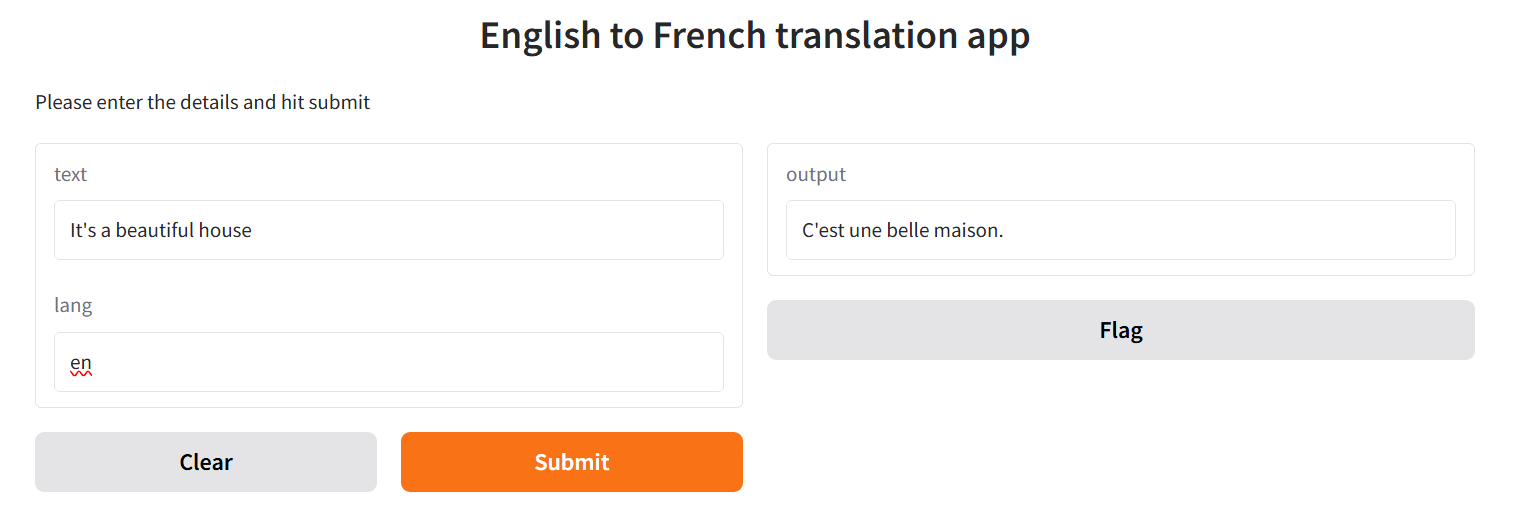

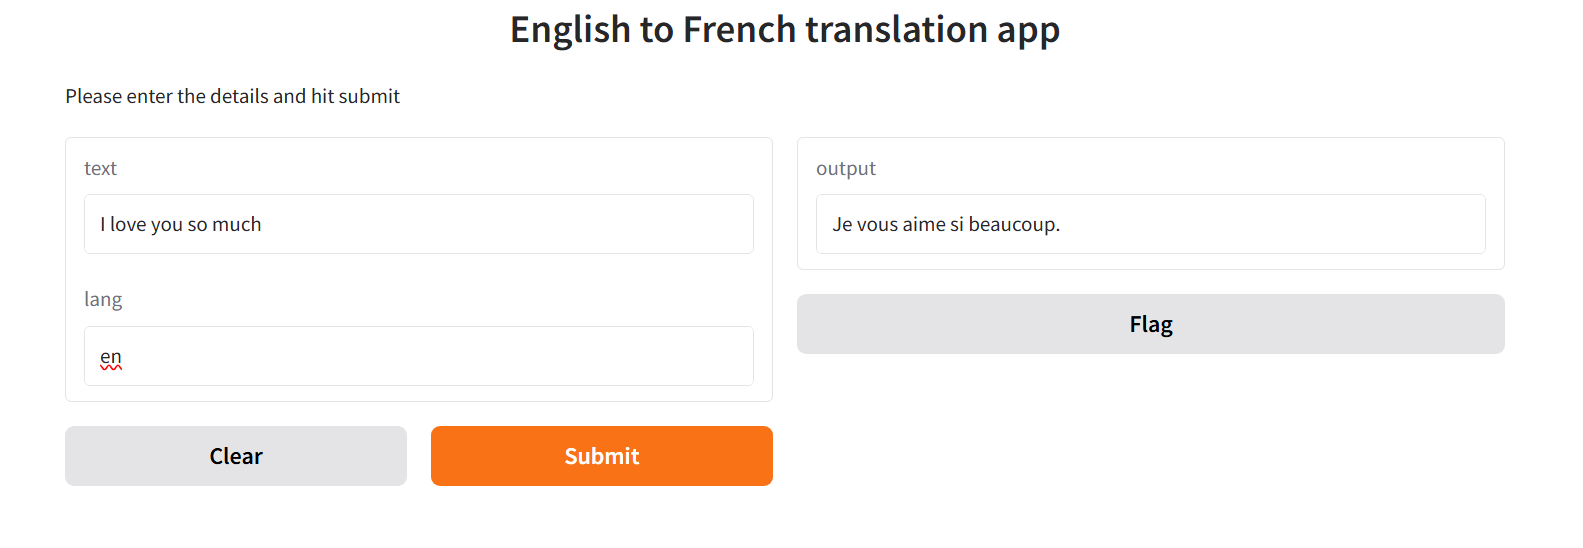

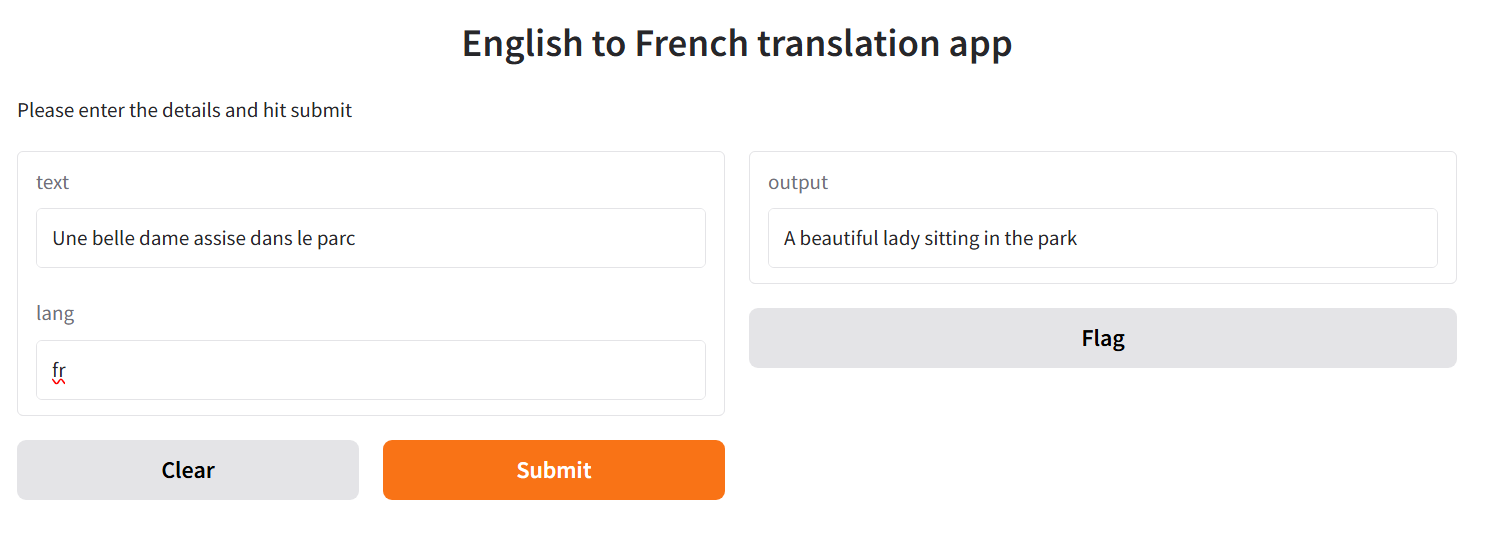

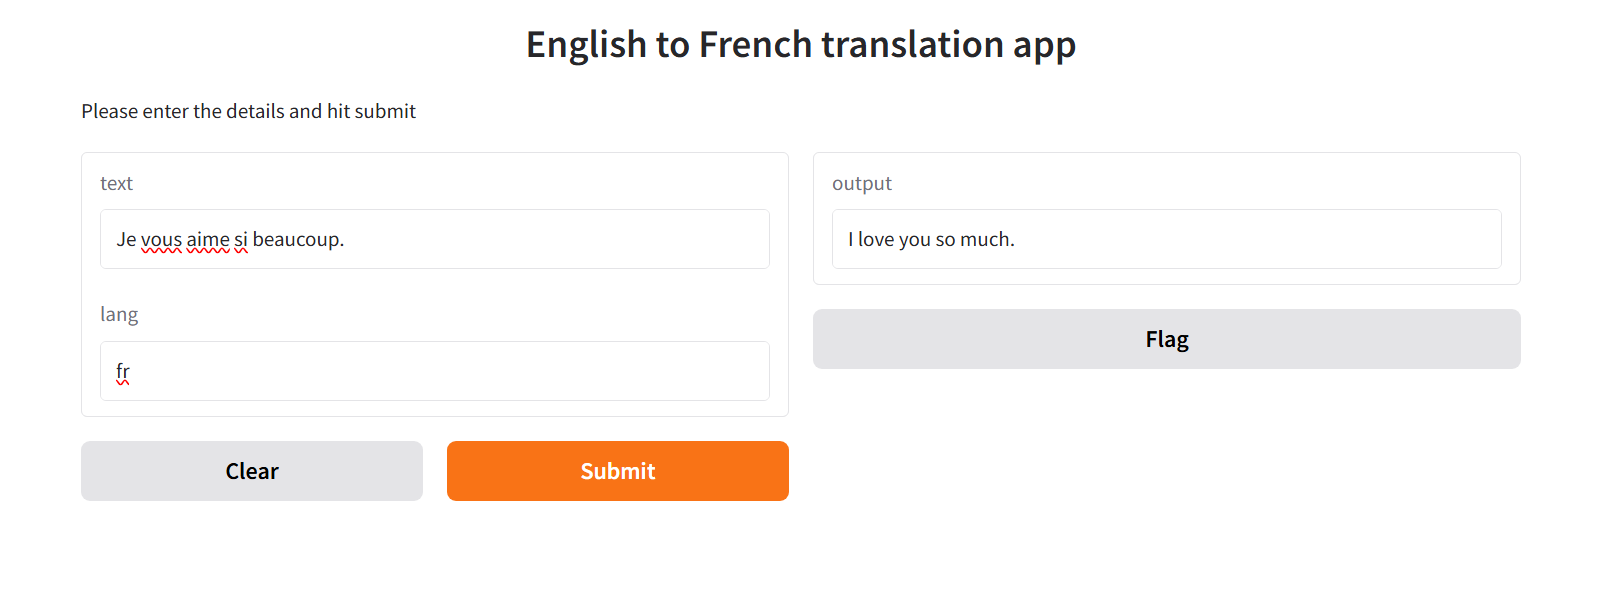

In [338]:
iface.close()

Closing server running on port: 7861
